# 04 · Statistical Analysis
Paired t-tests, Mann-Whitney U, Pearson correlations, and OLS regression.

**Research Questions:**
1. Does a hip-hop mention significantly change performance?
2. Does mention type (compliment/diss) predict the direction?
3. Does artist tier correlate with magnitude of change?
4. Does VADER sentiment predict outcome better than manual type?

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import pingouin as pg

%matplotlib inline
sns.set_theme(style='whitegrid')
df = pd.read_csv('../data/processed/normalized.csv')
df_valid = df.dropna(subset=['composite_delta_30g', 'before_PTS_mean', 'after_30g_PTS_mean'])
print(f"N = {len(df_valid)} complete mention windows")


N = 140 complete mention windows


In [2]:
# ── Q1: Paired t-tests — does a mention change performance? ──
print("=" * 60)
print("Q1: PAIRED T-TESTS — Before vs After (30-game window)")
print("=" * 60)
for stat in ['PTS', 'AST', 'REB']:
    before = df_valid[f'before_{stat}_mean']
    after  = df_valid[f'after_30g_{stat}_mean']
    t, p = stats.ttest_rel(after.dropna(), before.dropna())
    delta_mean = (after - before).mean()
    d = (after - before).mean() / (after - before).std()
    sig = "✓ SIGNIFICANT" if p < 0.05 else "✗ not significant"
    print(f"  {stat}: Δ={delta_mean:+.3f}  t={t:.3f}  p={p:.4f}  Cohen's d={d:.3f}  {sig}")


Q1: PAIRED T-TESTS — Before vs After (30-game window)
  PTS: Δ=+0.513  t=1.686  p=0.0940  Cohen's d=0.143  ✗ not significant
  AST: Δ=+0.043  t=0.454  p=0.6505  Cohen's d=0.038  ✗ not significant
  REB: Δ=+0.268  t=2.784  p=0.0061  Cohen's d=0.235  ✓ SIGNIFICANT


In [3]:
# ── Q2: Do compliments vs disses differ? (Mann-Whitney U) ──
print("\n" + "=" * 60)
print("Q2: MANN-WHITNEY U — Compliment vs Diss")
print("=" * 60)
for stat in ['PTS', 'AST', 'REB']:
    col = f'delta_after_30g_{stat}_adj'
    comp = df_valid[df_valid['mention_type']=='compliment'][col].dropna()
    diss = df_valid[df_valid['mention_type']=='diss'][col].dropna()
    if len(comp) >= 3 and len(diss) >= 3:
        u, p = stats.mannwhitneyu(comp, diss, alternative='two-sided')
        sig = "✓ SIGNIFICANT" if p < 0.05 else "✗ not significant"
        print(f"  {stat}: Compliment mean={comp.mean():+.3f}  Diss mean={diss.mean():+.3f}")
        print(f"         U={u:.1f}  p={p:.4f}  {sig}")



Q2: MANN-WHITNEY U — Compliment vs Diss
  PTS: Compliment mean=+0.438  Diss mean=+0.093
         U=385.5  p=0.4971  ✗ not significant
  AST: Compliment mean=+0.003  Diss mean=-0.040
         U=323.5  p=0.8679  ✗ not significant
  REB: Compliment mean=+0.206  Diss mean=+0.406
         U=284.5  p=0.4797  ✗ not significant


In [4]:
# ── Q3: Artist tier correlation ──
print("\n" + "=" * 60)
print("Q3: PEARSON CORRELATION — Artist Tier vs Stat Delta")
print("=" * 60)
for stat in ['PTS', 'AST', 'REB']:
    col = f'delta_after_30g_{stat}_adj'
    valid = df_valid[['artist_tier', col]].dropna()
    r, p = stats.pearsonr(valid['artist_tier'], valid[col])
    sig = "✓ SIGNIFICANT" if p < 0.05 else "✗ not significant"
    print(f"  Artist Tier → Δ{stat}: r={r:.3f}  p={p:.4f}  {sig}")



Q3: PEARSON CORRELATION — Artist Tier vs Stat Delta
  Artist Tier → ΔPTS: r=-0.080  p=0.3455  ✗ not significant
  Artist Tier → ΔAST: r=0.022  p=0.7993  ✗ not significant
  Artist Tier → ΔREB: r=-0.211  p=0.0123  ✓ SIGNIFICANT


In [5]:
# ── Q4: VADER sentiment vs delta ──
if 'vader_compound' in df_valid.columns:
    print("\n" + "=" * 60)
    print("Q4: PEARSON CORRELATION — VADER Sentiment vs Stat Delta")
    print("=" * 60)
    for stat in ['PTS', 'AST', 'REB']:
        col = f'delta_after_30g_{stat}_adj'
        valid = df_valid[['vader_compound', col]].dropna()
        r, p = stats.pearsonr(valid['vader_compound'], valid[col])
        sig = "✓ SIGNIFICANT" if p < 0.05 else "✗ not significant"
        print(f"  VADER → Δ{stat}: r={r:.3f}  p={p:.4f}  {sig}")



Q4: PEARSON CORRELATION — VADER Sentiment vs Stat Delta
  VADER → ΔPTS: r=-0.117  p=0.1681  ✗ not significant
  VADER → ΔAST: r=-0.012  p=0.8899  ✗ not significant
  VADER → ΔREB: r=-0.117  p=0.1671  ✗ not significant


In [6]:
# ── OLS Regression ──
print("\n" + "=" * 60)
print("MULTIPLE REGRESSION: composite_delta ~ predictors")
print("=" * 60)

# Encode mention_type as dummy vars
df_reg = df_valid.copy()
df_reg['type_compliment'] = (df_reg['mention_type'] == 'compliment').astype(int)
df_reg['type_diss']       = (df_reg['mention_type'] == 'diss').astype(int)

# Build formula using only columns that exist and have data
formula_parts = []
for col, label in [
    ('artist_tier',      'artist_tier'),
    ('type_compliment',  'type_compliment'),
    ('type_diss',        'type_diss'),
]:
    if col in df_reg.columns and df_reg[col].notna().sum() > 0:
        formula_parts.append(label)

if 'vader_compound' in df_reg.columns and df_reg['vader_compound'].notna().sum() > 0:
    formula_parts.append('vader_compound')

if not formula_parts:
    print("No valid predictor columns found — skipping regression.")
    print("Make sure notebooks 02 and 03 have been run first.")
else:
    # Use composite_delta_30g if available, otherwise fall back to raw PTS delta
    if 'composite_delta_30g' in df_reg.columns and df_reg['composite_delta_30g'].notna().sum() >= 5:
        outcome = 'composite_delta_30g'
    elif 'delta_after_30g_PTS_adj' in df_reg.columns and df_reg['delta_after_30g_PTS_adj'].notna().sum() >= 5:
        outcome = 'delta_after_30g_PTS_adj'
        print("Note: using delta_after_30g_PTS_adj as outcome (composite not available)")
    else:
        print("Insufficient data for regression. Run notebooks 02-03 first.")
        outcome = None

    if outcome:
        formula = f'{outcome} ~ ' + ' + '.join(formula_parts)
        print(f"Formula: {formula}")
        reg_data = df_reg[[outcome] + formula_parts].dropna()
        print(f"Rows used: {len(reg_data)}")

        if len(reg_data) < 5:
            print(f"\n⚠ Only {len(reg_data)} complete rows — not enough for regression.")
            print("This means the processed data files are missing. Run notebooks 01→02→03 first.")
        else:
            model = smf.ols(formula=formula, data=reg_data).fit()
            print(model.summary())



MULTIPLE REGRESSION: composite_delta ~ predictors
Formula: composite_delta_30g ~ artist_tier + type_compliment + type_diss + vader_compound
Rows used: 140
                             OLS Regression Results                            
Dep. Variable:     composite_delta_30g   R-squared:                       0.030
Model:                             OLS   Adj. R-squared:                  0.002
Method:                  Least Squares   F-statistic:                     1.057
Date:                 Tue, 07 Apr 2026   Prob (F-statistic):              0.380
Time:                         12:55:27   Log-Likelihood:                -272.87
No. Observations:                  140   AIC:                             555.7
Df Residuals:                      135   BIC:                             570.4
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                      coef    std err       

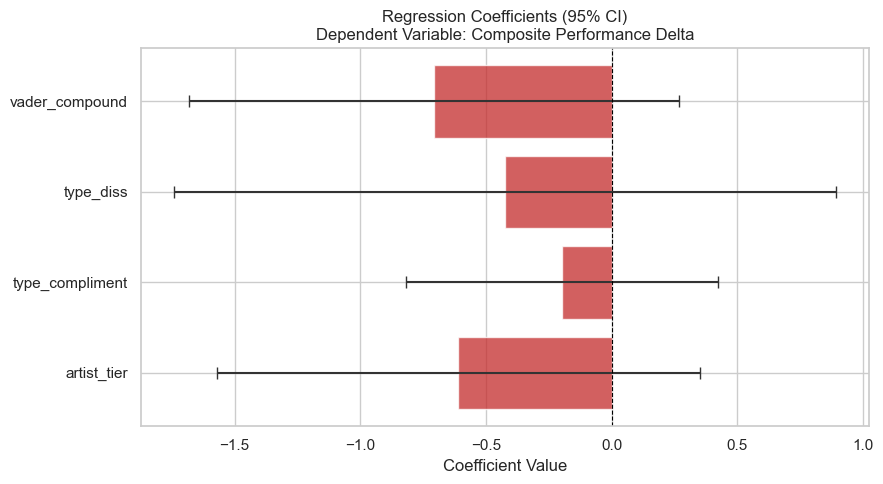


Model R² = 0.030  (Adjusted R² = 0.002)
F-statistic p-value = 0.3802


In [7]:
# Coefficient plot — only runs if model was successfully fit above
try:
    model
except NameError:
    print("Model not available — skipping coefficient plot. Run the regression cell first.")
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    coefs = model.params.drop('Intercept')
    cis   = model.conf_int().drop('Intercept')
    colors_coef = ['#1A8C50' if v > 0 else '#C42B2B' for v in coefs]
    ax.barh(coefs.index, coefs.values, color=colors_coef, alpha=0.75, edgecolor='white')
    ax.errorbar(coefs.values, range(len(coefs)),
                xerr=[coefs.values - cis[0].values, cis[1].values - coefs.values],
                fmt='none', color='#333', linewidth=1.5, capsize=4)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title('Regression Coefficients (95% CI)\nDependent Variable: Composite Performance Delta')
    ax.set_xlabel('Coefficient Value')
    plt.tight_layout()
    import os
    os.makedirs('../data/processed', exist_ok=True)
    plt.savefig('../data/processed/regression_coefficients.png', dpi=150)
    plt.show()
    print(f"\nModel R\u00b2 = {model.rsquared:.3f}  (Adjusted R\u00b2 = {model.rsquared_adj:.3f})")
    print(f"F-statistic p-value = {model.f_pvalue:.4f}")


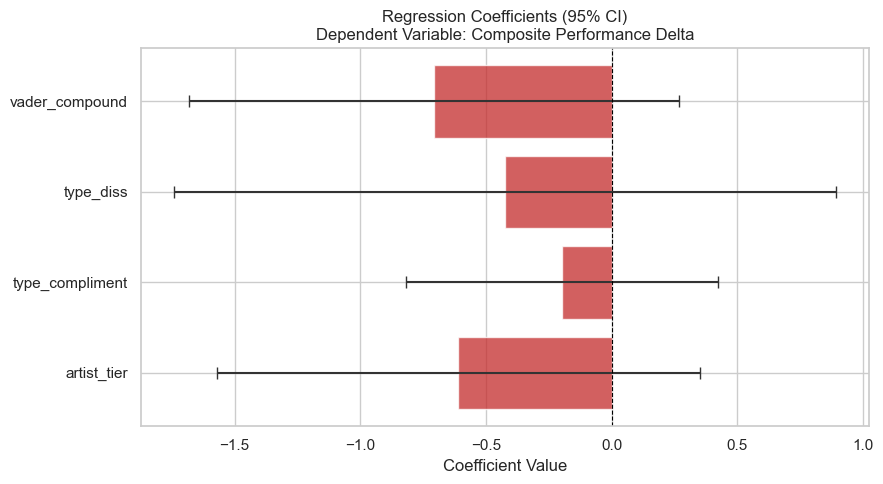


Model R² = 0.030 (Adjusted R² = 0.002)
F-statistic p-value = 3.8017e-01


In [8]:
import matplotlib.pyplot as plt

# Coefficient plot
fig, ax = plt.subplots(figsize=(9, 5))

# 1. Prepare data
coefs = model.params.drop('Intercept')
cis   = model.conf_int().drop('Intercept')

# 2. Map colors based on sign
colors_coef = ['#1A8C50' if v > 0 else '#C42B2B' for v in coefs]

# 3. Create Horizontal Bar Chart
ax.barh(coefs.index, coefs.values, color=colors_coef, alpha=0.75, edgecolor='white')

# 4. Corrected Error Bars
# The xerr for unequal intervals should be a (2, N) array: [lower_offsets, upper_offsets]
error_low = coefs.values - cis[0].values
error_high = cis[1].values - coefs.values

ax.errorbar(coefs.values, range(len(coefs)),
            xerr=[error_low, error_high],
            fmt='none', color='#333', linewidth=1.5, capsize=4)

# 5. Aesthetics & Labels
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

# Fixed the SyntaxError by using a single line or an f-string
ax.set_title('Regression Coefficients (95% CI)\nDependent Variable: Composite Performance Delta')
ax.set_xlabel('Coefficient Value')

plt.tight_layout()
plt.savefig('../data/processed/regression_coefficients.png', dpi=150)
plt.show()

# 6. Model Diagnostics
print(f"\nModel R² = {model.rsquared:.3f} (Adjusted R² = {model.rsquared_adj:.3f})")
print(f"F-statistic p-value = {model.f_pvalue:.4e}") # Changed to .4e in case it's very small